# Plotting Code for EXP3: Oracle controller

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from knapsack_solver import KnapsackSolver
import seaborn as sns
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [2]:
FILENAMES = {
    1: os.path.join('data','rouge_scores_ULS','Alpaca','ULS_4L_rouge_scores_24-08_12-32-15.csv'),
    #6: os.path.join('data','rouge_scores_ULS','Alpaca','ULS_6L_rouge_scores_24-08_11-57-16.csv'),
    2: os.path.join('data','rouge_scores_ULS','Alpaca','ULS_8L_rouge_scores_24-08_11-23-11.csv'),
    3: os.path.join('data','rouge_scores_ULS','Alpaca','ULS_12L_rouge_scores_24-08_10-49-11.csv'),
    6: os.path.join('data','rouge_scores_ULS','Alpaca','full_prop_rouge_scores_24-08_16-07-02.csv')
    }

df_dict = {
    k: pd.read_csv(v) for k, v in FILENAMES.items()
}

print(df_dict[6].head())

         hash    rouge1    rouge2    rougeL  label_length  prediction_length  \
0  2815121316  0.466667  0.214286  0.400000            24                 24   
1   308890434  0.000000  0.000000  0.000000             2                 14   
2  3089343928  0.240964  0.049383  0.168675            77                 39   
3   538035122  0.312102  0.057692  0.197452           230                143   
4  1997307462  0.560000  0.347826  0.560000            17                 14   

   prompt_length  
0             37  
1             45  
2             35  
3             37  
4             66  


In [32]:
values = np.vstack([df['rougeL'].values for df in df_dict.values()]).T
indices = np.vstack([[k]*len(df) for k, df in df_dict.items()]).T
#weights = np.vstack([[k*int(df['label_length'][i]) for i in range(len(df))]  for k, df in df_dict.items()]).T
weights = np.copy(indices)

#convert weights to integers
weights = weights.astype(int)
print(values[:5])
print(weights[:5])
print(indices[:5])
print(values.shape)
print(weights.shape)


[[0.01176471 0.23529412 0.2        0.4       ]
 [0.         0.         0.         0.        ]
 [0.07594937 0.15555556 0.09338521 0.1686747 ]
 [0.16299559 0.20155039 0.14342629 0.19745223]
 [0.4        0.26086957 0.56       0.56      ]]
[[1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]]
[[1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]
 [1 2 3 6]]
(7800, 4)
(7800, 4)


In [33]:
print(np.sum(weights, axis=0))
print(np.mean(df_dict[2]['label_length'].values))

[ 7800 15600 23400 46800]
56.70679487179487


In [34]:
#sort each row by value, and apply the same permutation to weights
sort_perm = np.argsort(-values, axis=1)
values_sorted = np.take_along_axis(values, sort_perm, axis=1)
weights_sorted = np.take_along_axis(weights, sort_perm, axis=1)
indices_sorted = np.take_along_axis(indices, sort_perm, axis=1)

In [35]:
print(values_sorted[:5])
print(weights_sorted[:5])
print(indices_sorted[:5])

[[0.4        0.23529412 0.2        0.01176471]
 [0.         0.         0.         0.        ]
 [0.1686747  0.15555556 0.09338521 0.07594937]
 [0.20155039 0.19745223 0.16299559 0.14342629]
 [0.56       0.56       0.4        0.26086957]]
[[6 2 3 1]
 [1 2 3 6]
 [6 2 3 1]
 [2 6 1 3]
 [3 6 1 2]]
[[6 2 3 1]
 [1 2 3 6]
 [6 2 3 1]
 [2 6 1 3]
 [3 6 1 2]]


In [36]:
max_capacity = sum(max(w) for w in weights_sorted)
print(max_capacity)

46800


In [37]:
kp_solver = KnapsackSolver(values_sorted, weights_sorted, indices_sorted, shard_number=16, max_layer=6)

kp_solver.solve()

In [38]:
betas = [x/100.0 for x in range(100, 600)]
optimal_rouges = np.array([kp_solver.get_optimal_value(beta) for beta in betas])

In [45]:
ULS_constant_rouges = [df['rougeL'].mean() for df in df_dict.values()]
ULS_layer_use = [k*4 for k in df_dict.keys()]

optimal_rouge_layer_use = [b*4 for b in betas]

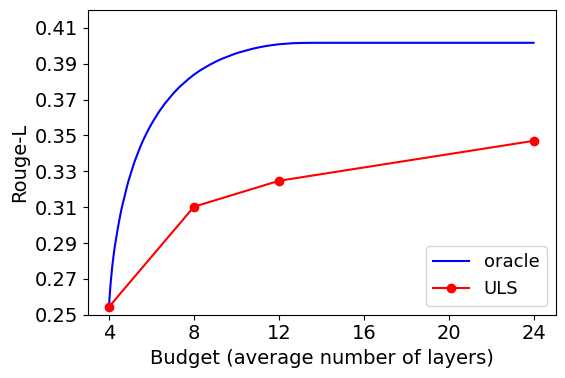

In [61]:
plt.figure(figsize=(6,4))
#font size
plt.rc('font', size=14)
plt.plot(optimal_rouge_layer_use, optimal_rouges, label='oracle', color='blue')
#scatter with line connecting points
plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='red', marker='o')
#compare AUC
#plt.fill_between(ULS_layer_use, ULS_constant_rouges, alpha=0.2, color='red')
#plt.fill_between(optimal_rouge_layer_use, optimal_rouges, alpha=0.2, color='blue')
plt.xlabel('Budget (average number of layers)')
plt.ylabel('Rouge-L')
#change y range
plt.ylim(0.25, 0.42)
plt.legend(loc='lower right', fontsize=13)
#plt.xticks(np.arange(8, 25, 1))
plt.xticks(np.arange(1*4, 6*4 + 0.001, 1*4))
plt.tight_layout()
plt.yticks(np.arange(0.25, 0.42, 0.02))
#save pdf
plt.savefig(r"data\rouge_scores_ULS\Alpaca\oracle.pdf", bbox_inches='tight')
plt.show()
#why is savefig showing a blank image?
#A: 



In [177]:
average_layers = [1, 1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5,3.75,4,4.25,4.5,4.75,5,5.25,5.5,5.75,6]
choices_for_layer = [kp_solver.reconstruct_chosen_items(layer) for layer in average_layers]
occurences_model = [[0,0,0,0] for _ in range(len(choices_for_layer))]
for i in range(len(choices_for_layer)):
    occurences_model[i][0] += choices_for_layer[i].count(1) / values.shape[0]
    occurences_model[i][1] += choices_for_layer[i].count(2) / values.shape[0]
    occurences_model[i][2] += choices_for_layer[i].count(3) / values.shape[0]
    occurences_model[i][3] += choices_for_layer[i].count(6) / values.shape[0]

In [180]:
occurences_model_np = np.array(occurences_model)
layer5 = occurences_model_np[1]
layer6 = occurences_model_np[2]
layer5_6 = layer5*0.4 + layer6*0.6
print(layer5_6)


[0.69587179 0.22812821 0.06787179 0.00812821]


5.600106633798867


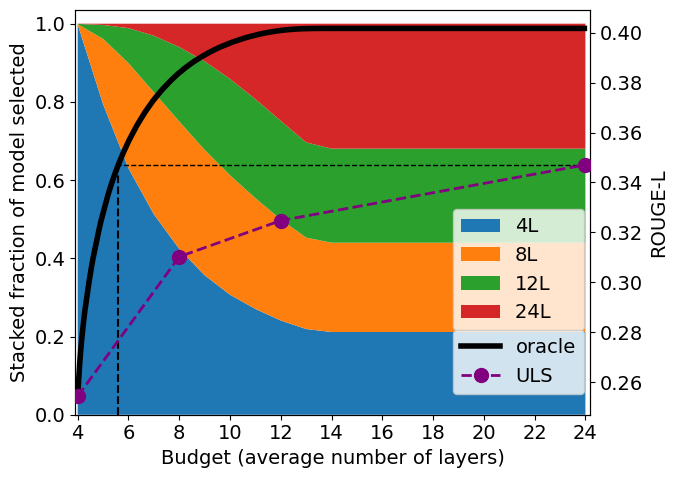

In [172]:
#default style
plt.figure(figsize=(7,5))
#font size
plt.rc('font', size=14)
# plot as stacked line chart,
plt.stackplot([a*4 for a in average_layers], occurences_model_np.T, labels=['4L', '8L', '12L', '24L    '])
#plt.plot(np.arange(8,25,1), budget_used, color='purple', linewidth=2)
plt.legend(loc=(0.733,0.209))
plt.xlabel('Budget (average number of layers)')
plt.ylabel('Stacked fraction of model selected')

#add vertical dashed line at 15
# plt.axvline(x=14, color='black', linestyle='--',ymax=0.96)
# #add text of values of occurences_model at 12
# for i, txt in enumerate(occurences_model_np[10]):
#     plt.text(14 +0.1, sum(occurences_model_np[10,:i]) + 0.48*occurences_model_np[10,i], str(round(txt,2)), color='black')

# for i, txt in enumerate(occurences_model_np[4]):
#     plt.text(11.1, sum(occurences_model_np[4,:i]) + 0.38*occurences_model_np[4,i], str(round(txt,2)), color='black')
plt.grid(False)
plt.ylim(0,1.035)
#add rouge socre on secondary y axis
plt.twinx()
plt.ylabel('ROUGE-L')
plt.plot(optimal_rouge_layer_use, optimal_rouges, label='oracle', color='black', linewidth=4)

plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='purple', marker='o', linestyle='--', linewidth=2, markersize=10, zorder=10)

#add horizontal dashed line at full model
plt.axhline(y=ULS_constant_rouges[-1], color='black', linestyle='--',xmin=0.08, linewidth=1)

#intesecting point of max uls and oracle
intersect = np.interp(ULS_constant_rouges[-1], optimal_rouges, optimal_rouge_layer_use)
print(intersect)
plt.axvline(x=intersect, color='black', linestyle='--',ymax=0.63)

#plt.ylim(0.277, 0.360)
#plt.ylim(0.37, 0.447)

plt.legend(loc=(0.734,0.052))
#hide grid 
plt.grid(False)
plt.xlim(3.9,24.2)
plt.xticks(np.arange(4,25,2))
plt.tight_layout()
plt.savefig(r"data\rouge_scores_ULS\Alpaca\oracle_stacked.pdf", bbox_inches='tight')
plt.show()

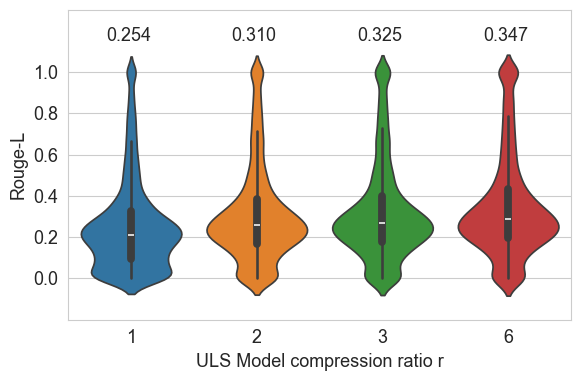

In [12]:
sns.set_style('whitegrid')
#violin plots of rouge scores, colorful
plt.figure(figsize=(6,4))
violin_data = {
    '1': df_dict[1]['rougeL'],
    '2': df_dict[2]['rougeL'],
    '3': df_dict[3]['rougeL'],
    '6': df_dict[6]['rougeL'],
}
sns.violinplot(data=violin_data)
#show average rouge scores
for i, (k, v) in enumerate(violin_data.items()):
    plt.text(i, v.mean(), f'{v.mean():.3f}', position=(i-0.2,1.15))
plt.xticks(np.arange(4), ['1', '2', '3', '6'])
plt.ylim(-0.2, 1.3)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylabel('Rouge-L')
plt.xlabel('ULS Model compression ratio r')
plt.tight_layout()